# Emotion Recognition from Speech

**CodeAlpha Internship Task 2 - Overfitting Improvement**

## Objective
The objective of this project is to build a machine-learning/deep-learning system that recognizes human emotions from speech audio using MFCC features and a neural network classifier. We will use the RAVDESS dataset, extract features using `librosa`, and train a Convolutional Neural Network (CNN) to classify the emotions. We also include data augmentation to reduce overfitting.

## Import Libraries

In [1]:
import os
import glob
import shutil
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import librosa
import librosa.display
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Activation, Flatten, Conv1D, MaxPooling1D, BatchNormalization, GlobalAveragePooling1D
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import kagglehub


## Dataset
We are using the **RAVDESS (Ryerson Audio-Visual Database of Emotional Speech and Song)** dataset.

In [2]:
EXTRACT_DIR = "data/raw"
os.makedirs("data", exist_ok=True)
os.makedirs(EXTRACT_DIR, exist_ok=True)

if not os.listdir(EXTRACT_DIR):
    print("Downloading RAVDESS dataset via kagglehub...")
    path = kagglehub.dataset_download("uwrfkaggler/ravdess-emotional-speech-audio")
    print("Download complete. Copying to data/raw...")
    for root, dirs, files in os.walk(path):
        for file in files:
            if file.endswith('.wav'):
                src_path = os.path.join(root, file)
                dest_path = os.path.join(EXTRACT_DIR, file)
                shutil.copy2(src_path, dest_path)
    print("Dataset ready in data/raw/")
else:
    print("Dataset already extracted in data/raw/")


Dataset already extracted in data/raw/


## Audio Exploration

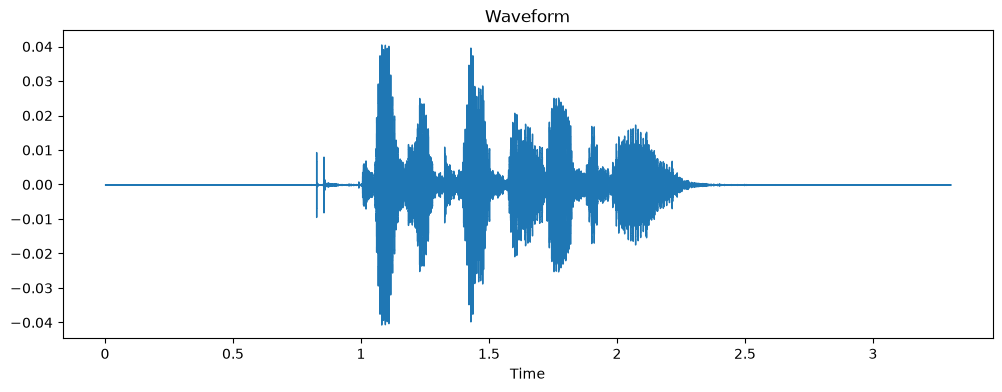

In [3]:
sample_files = glob.glob(f"{EXTRACT_DIR}/**/*.wav", recursive=True)
if len(sample_files) > 0:
    sample_file = sample_files[0]
    data, sample_rate = librosa.load(sample_file, sr=None)
    
    plt.figure(figsize=(12, 4))
    librosa.display.waveshow(data, sr=sample_rate)
    plt.title("Waveform")
    plt.show()


## Emotion Labels

In [4]:
emotion_dict = {
    '01': 'neutral',
    '02': 'calm',
    '03': 'happy',
    '04': 'sad',
    '05': 'angry',
    '06': 'fearful',
    '07': 'disgust',
    '08': 'surprised'
}


## Audio Augmentation & MFCC Extraction
We apply small random Gaussian noise and time shift for augmentation, ONLY on training data to prevent data leakage.

In [5]:
def add_noise(data, noise_factor=0.005):
    noise = np.random.randn(len(data))
    return data + noise_factor * noise

def shift_time(data, sampling_rate, shift_max=0.05):
    shift = np.random.randint(int(sampling_rate * shift_max))
    direction = np.random.choice([-1, 1])
    if direction == 1:
        shift = -shift
    augmented_data = np.roll(data, shift)
    if shift > 0:
        augmented_data[:shift] = 0
    else:
        augmented_data[shift:] = 0
    return augmented_data

def extract_mfcc_from_data(audio, sample_rate, n_mfcc=40):
    mfcc = librosa.feature.mfcc(y=audio, sr=sample_rate, n_mfcc=n_mfcc)
    return np.mean(mfcc.T, axis=0)

def process_audio(file_path, augment=False):
    try:
        audio, sample_rate = librosa.load(file_path, sr=22050)
        features = [extract_mfcc_from_data(audio, sample_rate)]
        
        if augment:
            # Add noise augmented sample
            features.append(extract_mfcc_from_data(add_noise(audio), sample_rate))
            # Add time shifted augmented sample
            features.append(extract_mfcc_from_data(shift_time(audio, sample_rate), sample_rate))
            
        return features
    except Exception as e:
        return []


## Dataset Preparation
Split filenames BEFORE feature extraction and augmentation to ensure zero data leakage.

In [6]:
all_files = glob.glob(f"{EXTRACT_DIR}/**/*.wav", recursive=True)
file_paths = []
labels = []

for file in all_files:
    filename = os.path.basename(file)
    parts = filename.split('-')
    if len(parts) >= 3:
        emotion_code = parts[2]
        if emotion_code in emotion_dict:
            file_paths.append(file)
            labels.append(emotion_code)

unique_labels = sorted(list(set(labels)))
label_to_int = {label: i for i, label in enumerate(unique_labels)}
int_to_label = {i: label for label, i in label_to_int.items()}

labels_encoded = np.array([label_to_int[label] for label in labels])

# Train / Test split on filenames
X_train_paths, X_test_paths, y_train_lbls, y_test_lbls = train_test_split(
    file_paths, labels_encoded, test_size=0.2, random_state=42, stratify=labels_encoded
)

print(f"Train files: {len(X_train_paths)}, Test files: {len(X_test_paths)}")

X_train, y_train = [], []
for path, label in zip(X_train_paths, y_train_lbls):
    feats = process_audio(path, augment=True) # Apply augmentation on train
    for f in feats:
        X_train.append(f)
        y_train.append(label)

X_test, y_test = [], []
for path, label in zip(X_test_paths, y_test_lbls):
    feats = process_audio(path, augment=False) # No augmentation on test
    for f in feats:
        X_test.append(f)
        y_test.append(label)

X_train = np.array(X_train)
y_train = np.array(y_train)
X_test = np.array(X_test)
y_test = np.array(y_test)

print(f"Train samples (after aug): {X_train.shape[0]}, Test samples: {X_test.shape[0]}")


Train files: 1152, Test files: 288


Train samples (after aug): 3456, Test samples: 288


## Feature Normalization
Standardize features fit ONLY on training data.

In [7]:
scaler = StandardScaler()
X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Reshape data for Conv1D input
X_train = np.expand_dims(X_train, axis=2)
X_test = np.expand_dims(X_test, axis=2)


## Neural Network Model
Reduced complexity and increased dropout to 0.45 to prevent overfitting.

In [8]:
def build_model(input_shape, num_classes):
    model = Sequential()
    
    # Reduced filters from 64 to 32
    model.add(Conv1D(32, kernel_size=5, padding='same', activation='relu', input_shape=input_shape))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    # Reduced filters from 128 to 64
    model.add(Conv1D(64, kernel_size=5, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(MaxPooling1D(pool_size=2))
    
    # Increased dropout to 0.4
    model.add(Dropout(0.4))
    
    # Reduced filters from 256 to 128
    model.add(Conv1D(128, kernel_size=5, padding='same', activation='relu'))
    model.add(BatchNormalization())
    model.add(GlobalAveragePooling1D())
    
    # Increased dropout to 0.4
    model.add(Dropout(0.4))
    
    model.add(Dense(64, activation='relu'))
    model.add(Dropout(0.4))
    
    model.add(Dense(num_classes, activation='softmax'))
    
    return model

num_classes = len(unique_labels)
model = build_model((X_train.shape[1], X_train.shape[2]), num_classes)
model.summary()


C:\Users\abhin\Desktop\CodeAlpha_EmotionRecognition\.venv\Lib\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv1d (Conv1D)                 │ (None, 40, 32)         │           192 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization             │ (None, 40, 32)         │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d (MaxPooling1D)    │ (None, 20, 32)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_1 (Conv1D)               │ (None, 20, 64)         │        10,304 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_1           │ (None, 20, 64)         │           256 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling1d_1 (MaxPooling1D)  │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout (Dropout)               │ (None, 10, 64)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv1d_2 (Conv1D)               │ (None, 10, 128)        │        41,088 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_2           │ (None, 10, 128)        │           512 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ global_average_pooling1d        │ (None, 128)            │             0 │
│ (GlobalAveragePooling1D)        │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_1 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_2 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 8)              │           520 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 61,256 (239.28 KB)

 Trainable params: 60,808 (237.53 KB)

 Non-trainable params: 448 (1.75 KB)

## Model Compilation

In [9]:
model.compile(optimizer='adam', 
              loss='sparse_categorical_crossentropy', 
              metrics=['accuracy'])


## Training

In [10]:
early_stopping = EarlyStopping(monitor='val_loss', patience=8, restore_best_weights=True, verbose=1)
lr_reducer = ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=3, min_lr=1e-6, verbose=1)

os.makedirs("results", exist_ok=True)

history = model.fit(X_train, y_train, 
                    epochs=70, 
                    batch_size=32, 
                    validation_data=(X_test, y_test), 
                    callbacks=[early_stopping, lr_reducer],
                    verbose=1)


Epoch 1/70


  1/108 ━━━━━━━━━━━━━━━━━━━━ 3:49 2s/step - accuracy: 0.1562 - loss: 2.2242

  7/108 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - accuracy: 0.1786 - loss: 2.2142

 13/108 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.1587 - loss: 2.1848

 19/108 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.1513 - loss: 2.2016 

...

 93/108 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7436 - loss: 0.7334

102/108 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - accuracy: 0.7426 - loss: 0.7336

108/108 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.7396 - loss: 0.7368 - val_accuracy: 0.6840 - val_loss: 1.0485 - learning_rate: 1.5625e-05


Epoch 49: early stopping


Restoring model weights from the end of the best epoch: 41.


## Training History

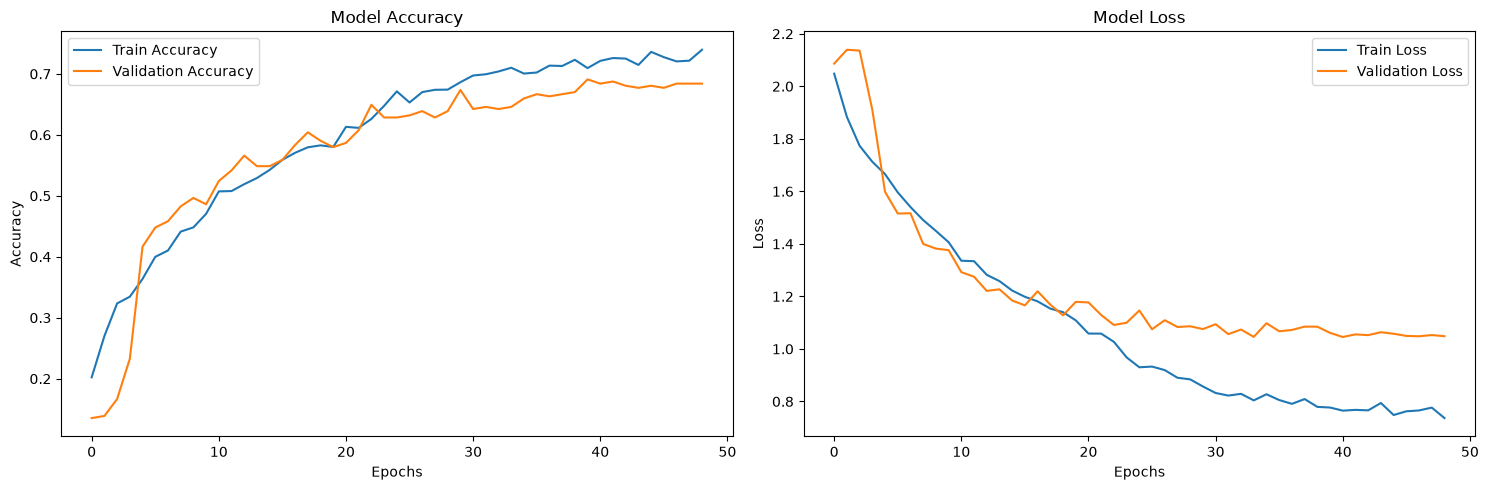

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(15, 5))

axes[0].plot(history.history['accuracy'], label='Train Accuracy')
axes[0].plot(history.history['val_accuracy'], label='Validation Accuracy')
axes[0].set_title('Model Accuracy')
axes[0].set_xlabel('Epochs')
axes[0].set_ylabel('Accuracy')
axes[0].legend()

axes[1].plot(history.history['loss'], label='Train Loss')
axes[1].plot(history.history['val_loss'], label='Validation Loss')
axes[1].set_title('Model Loss')
axes[1].set_xlabel('Epochs')
axes[1].set_ylabel('Loss')
axes[1].legend()

plt.tight_layout()
plt.savefig('results/training_history_improved.png')
plt.show()

# Get best validation accuracy and loss
best_epoch = np.argmin(history.history['val_loss'])
val_loss = history.history['val_loss'][best_epoch]
val_acc = history.history['val_accuracy'][best_epoch]


## Evaluation

In [12]:
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Test Accuracy: {test_acc:.4f}")

y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)

acc = accuracy_score(y_test, y_pred)
prec = precision_score(y_test, y_pred, average='weighted', zero_division=0)
rec = recall_score(y_test, y_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

print(f"Accuracy: {acc:.4f}")
print(f"Precision: {prec:.4f}")
print(f"Recall: {rec:.4f}")
print(f"F1-Score: {f1:.4f}")

target_names = [emotion_dict[int_to_label[i]] for i in range(num_classes)]
print("\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=target_names, zero_division=0))


Test Accuracy: 0.6840


1/9 ━━━━━━━━━━━━━━━━━━━━ 1s 199ms/step

9/9 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step  


Accuracy: 0.6840
Precision: 0.7177
Recall: 0.6840
F1-Score: 0.6818

Classification Report:
              precision    recall  f1-score   support

     neutral       0.61      0.58      0.59        19
        calm       0.72      0.82      0.77        38
       happy       0.63      0.68      0.66        38
         sad       0.86      0.63      0.73        38
       angry       0.88      0.72      0.79        39
     fearful       0.80      0.41      0.54        39
     disgust       0.67      0.68      0.68        38
   surprised       0.52      0.90      0.66        39

    accuracy                           0.68       288
   macro avg       0.71      0.68      0.68       288
weighted avg       0.72      0.68      0.68       288



## Confusion Matrix

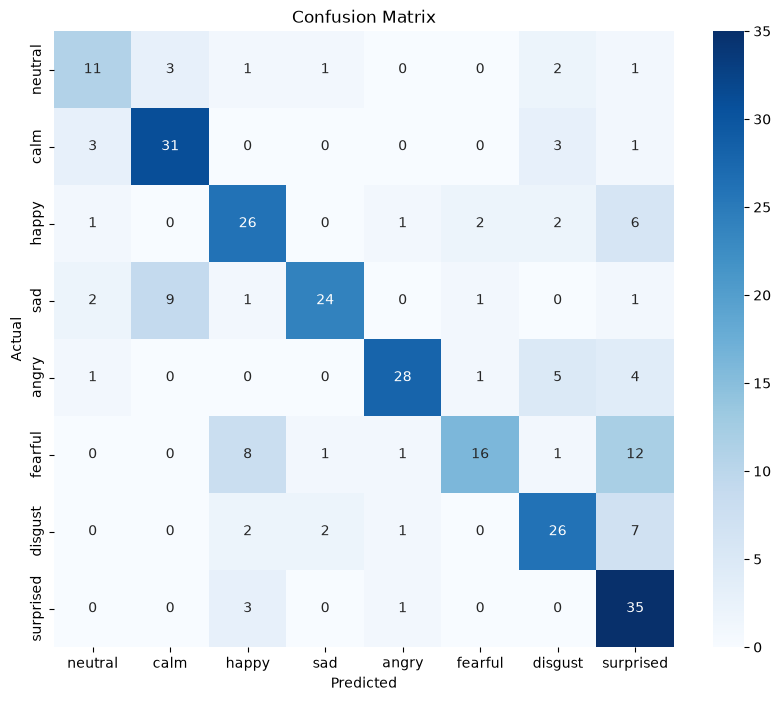

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(10, 8))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=target_names, yticklabels=target_names)
plt.title('Confusion Matrix')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.savefig('results/confusion_matrix_improved.png')
plt.show()


## Sample Predictions

In [14]:
num_samples = 5
indices = np.random.choice(len(y_test), num_samples, replace=False)


## Model Saving

In [15]:
os.makedirs("models", exist_ok=True)
model_path = 'models/improved_emotion_model.keras'
model.save(model_path)
print(f"Model saved to {model_path}")


Model saved to models/improved_emotion_model.keras


## Results

In [16]:
with open('results/improved_metrics.txt', 'w') as f:
    f.write("Emotion Recognition from Speech\n")
    f.write("Model: Conv1D (Improved)\n\n")
    f.write(f"Accuracy: {acc:.4f}\n")
    f.write(f"Precision: {prec:.4f}\n")
    f.write(f"Recall: {rec:.4f}\n")
    f.write(f"F1-Score: {f1:.4f}\n")
    f.write(f"Validation Accuracy: {val_acc:.4f}\n")
    f.write(f"Validation Loss: {val_loss:.4f}\n")
print("Metrics saved to results/improved_metrics.txt")


Metrics saved to results/improved_metrics.txt
